In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

plt.rcParams['figure.figsize'] = [10, 6]

In [2]:
compton = pd.read_csv("Compton - material wtv.csv")

scat_angle = compton['angle']
cnt = compton['NET count']
unccnt = compton['cnt uncertainty']
energy = compton['energy (keV)']
time = compton['live time (s)']

# Part 1

In [3]:
angle = np.radians(scat_angle)
angle_err = np.radians(2) # it was impossible to see if i was directly on the correct angle

inv_energy = 1 / energy * 1e+3 # keV -> MeV
plot_angle = 1 - np.cos(angle)

plot_angle_err = np.sin(angle) * angle_err

def fit(m,x,c):
    return m*x+c

popt, pcov = curve_fit(fit, plot_angle, inv_energy)
m, c = popt
fit_err = np.sqrt(np.diag(pcov))

m_th = 1.956
c_th = 1.51

ang_range = np.linspace(plot_angle.min(), plot_angle.max(), 100)
fit_th = m_th * ang_range + c_th

slope_err = np.abs((m - m_th) / m_th) * 100
intcpt_err = np.abs((c - c_th) / c_th) * 100

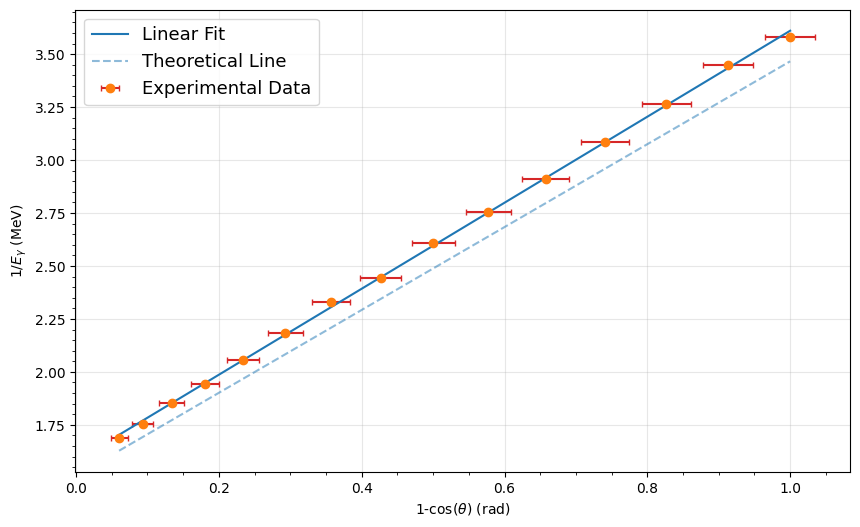

Slope: 2.030 ± 0.0120
Intercept: 1.58 ± 0.007
Slope Percentage Error: 3.77%
Intercept Percentage Error: 4.68%


In [4]:
plt.errorbar(plot_angle, inv_energy, xerr=plot_angle_err, fmt='o', color='tab:orange', ecolor='tab:red', capsize=2, label='Experimental Data')
plt.plot(plot_angle, fit(plot_angle, *popt), '-', color='tab:blue', label='Linear Fit')
plt.plot(ang_range, fit_th, '--', color='tab:blue', alpha=0.5, label='Theoretical Line')

plt.xlabel(r'1-$\cos(\theta)$ (rad)')
plt.ylabel(r'1/$E_{\gamma}$ (MeV)') # since theoretical used MeV values
plt.minorticks_on()
plt.grid(alpha=0.3)
plt.legend(fontsize=13)

plt.show()

print(f'Slope: {m:.3f} ± {fit_err[0]:.4f}')
print(f'Intercept: {c:.2f} ± {fit_err[1]:.3f}')
print(f'Slope Percentage Error: {slope_err:.2f}%')
print(f'Intercept Percentage Error: {intcpt_err:.2f}%')

# Part 2

In [43]:
r_det = 2.5 # cm
dist = 26 # cm
M_rod = 79.3 # g
Z_Al = 13
A_Al = 26.9815
Na = 6.02e+23

domega  = (np.pi * r_det**2) / dist**2 # solid angle (steradians)
N = (M_rod * Z_Al * Na) / A_Al # no. of electrons in scattering sample

def int_energy(energy):
    energy_mev = energy * 1e-3
    return 0.1522 * (energy_mev**(-1.1325))

eff = int_energy(energy)
cnt_rate = cnt / time
crosssect = cnt_rate / (N * domega * eff)

crosssect_unc = crosssect * (unccnt / cnt)
theta_err = 2

def KN(theta, energy_Cs=661.7e-3): # putting it immediately in MeV
    alpha = energy_Cs / 0.511
    thetar = np.radians(theta)
    cos = np.cos(thetar)

    p1 = (1 + cos**2) / (1 + alpha * (1 - cos))**2
    p2 = 1 + ((alpha**2 * (1 - cos)**2) / ((1+ cos**2) * (1 + alpha * (1 - cos))))

    r0 = 2.82e-13 # cm
    return (r0**2) / 2 * p1 * p2

range_theta = np.linspace(0, 100, 100)
th_val = [KN(i) for i in range_theta]

scale = KN(20) / crosssect[0]
norm_data = crosssect * scale # normalised (scaled to KN)
norm_err = crosssect_unc * scale

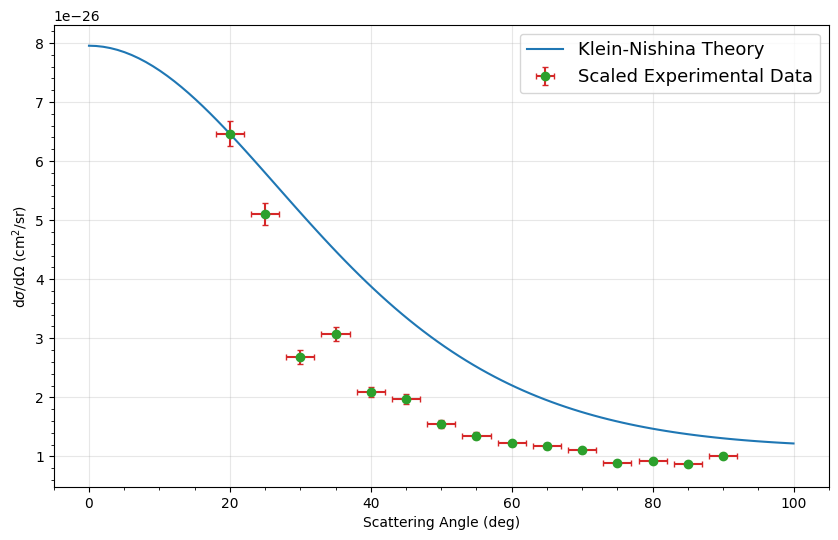

In [44]:
plt.errorbar(scat_angle, norm_data, yerr=norm_err, xerr=theta_err, fmt='o', color='tab:green', ecolor='tab:red', capsize=2, label='Scaled Experimental Data')
plt.plot(range_theta, th_val, color='tab:blue', label='Klein-Nishina Theory')

plt.xlabel(r'Scattering Angle (deg)')
plt.ylabel(r'd$\sigma$/d$\Omega$ (cm$^2$/sr)')
plt.minorticks_on()
plt.grid(alpha=0.3)
plt.legend(fontsize=13)

plt.show()